# Experiment: Shock Meta XGBoost Optuna Lab

Objective: run a controlled Optuna workflow for the BTCUSD 1h shock-meta XGBoost pipeline.

This notebook uses `config/optuna/optuna_shock_meta_xgboost.yaml` as the Optuna spec and `config/experiments/btcusd_1h_shock_meta_xgboost.yaml` as the fixed base pipeline. The search space is intentionally small and selector-based so feature window changes do not break model inputs.


## Guardrails

- Keep `RUN_OPTUNA = False` until the feature preview and baseline config checks pass.
- Treat Optuna results as in-sample research candidates, not production evidence.
- Rank trading candidates using only `COMPLETE` trials. `PRUNED` trial values are intermediate pruning metrics, not final Sharpe/objective values.
- Prefer stability across folds over a single high Sharpe trial.
- Do not expand the search space before reviewing trial count, trade count, drawdown, turnover, and cost drag.


In [1]:
# Setup: imports, paths, and reproducibility
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

repo_root = Path.cwd().resolve()
if not (repo_root / 'src').exists():
    repo_root = next(parent for parent in Path.cwd().resolve().parents if (parent / 'src').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.experiments import runner as runner_mod
from src.experiments.optuna_search import (
    normalize_objective_spec,
    normalize_pruning_spec,
    normalize_search_space,
    optimize_experiment,
    prepare_trial_config,
)
from src.experiments.support.notebook_lab import (
    build_analysis_frame_from_result,
    build_summary_frame,
    run_experiment_from_config,
)
from src.models.runtime import infer_feature_columns
from src.utils.config import load_experiment_config
from src.utils.config_validation import validate_resolved_config

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
SEED = 7
np.random.seed(SEED)
warnings.filterwarnings('ignore', category=FutureWarning)


In [2]:
# Config: edit only these flags for normal experimentation.
OPTUNA_SPEC_PATH = repo_root / 'config/optuna/optuna_shock_meta_xgboost.yaml'

# Safe default: preview only. For a quick search use RUN_OPTUNA=True and N_TRIALS_OVERRIDE=3 or 5.
RUN_BASELINE = True
RUN_OPTUNA = True
RUN_BEST_TRIAL = True
BASELINE_SAMPLE_ROWS = 2_500
N_TRIALS_OVERRIDE = 30  # None uses study.n_trials from the Optuna YAML.

with OPTUNA_SPEC_PATH.open('r', encoding='utf-8') as handle:
    OPTUNA_SPEC = yaml.safe_load(handle) or {}

BASE_CONFIG_PATH = repo_root / OPTUNA_SPEC['base_config']
BASE_CFG = load_experiment_config(BASE_CONFIG_PATH)
SEARCH_SPACE = normalize_search_space(OPTUNA_SPEC['search_space'])
OBJECTIVE = normalize_objective_spec(OPTUNA_SPEC.get('objective'))
PRUNING = normalize_pruning_spec(OPTUNA_SPEC.get('pruning'))
STUDY_CFG = dict(OPTUNA_SPEC.get('study', {}) or {})

validate_resolved_config(BASE_CFG)

print(f'Optuna spec: {OPTUNA_SPEC_PATH.relative_to(repo_root)}')
print(f'Base config:  {BASE_CONFIG_PATH.relative_to(repo_root)}')
print(f'Search dims:  {len(SEARCH_SPACE)}')
print(f'Objective:    {OBJECTIVE.metric_path} ({OBJECTIVE.direction})')
print(f'Pruning:      enabled={PRUNING.enabled}, metric={PRUNING.metric_path}')


Optuna spec: config/optuna/optuna_shock_meta_xgboost.yaml
Base config:  config/experiments/btcusd_1h_shock_meta_xgboost.yaml
Search dims:  40
Objective:    evaluation.primary_summary.sharpe (maximize)
Pruning:      enabled=True, metric=classification_metrics.roc_auc


In [3]:
# Small display helpers
def show_df(title: str, frame: pd.DataFrame, rows: int = 20) -> pd.DataFrame:
    display(Markdown(f'### {title}'))
    if frame.empty:
        display(Markdown('_empty_'))
        return frame
    display(frame.head(rows))
    return frame


def flatten_dict(d: dict, prefix: str = '') -> dict:
    out = {}
    for key, value in dict(d or {}).items():
        name = f'{prefix}.{key}' if prefix else str(key)
        if isinstance(value, dict):
            out.update(flatten_dict(value, name))
        else:
            out[name] = value
    return out


def _bool_col(frame: pd.DataFrame, col: str) -> pd.Series:
    if col not in frame.columns:
        return pd.Series(False, index=frame.index)
    return frame[col].fillna(False).astype(bool)


def metric_comparison_frame(*, baseline_summary: dict | None, candidate_summary: dict | None) -> pd.DataFrame:
    metrics = [
        'sharpe',
        'sortino',
        'cumulative_return',
        'annualized_return',
        'profit_factor',
        'hit_rate',
        'max_drawdown',
        'gross_pnl',
        'net_pnl',
        'total_cost',
        'total_turnover',
        'cost_to_gross_pnl',
    ]
    rows = []
    baseline_summary = dict(baseline_summary or {})
    candidate_summary = dict(candidate_summary or {})
    for metric in metrics:
        base_value = baseline_summary.get(metric, np.nan)
        candidate_value = candidate_summary.get(metric, np.nan)
        rows.append(
            {
                'metric': metric,
                'baseline': base_value,
                'candidate': candidate_value,
                'delta': candidate_value - base_value if pd.notna(base_value) and pd.notna(candidate_value) else np.nan,
            }
        )
    return pd.DataFrame(rows)


def load_local_dukascopy_frame(cfg: dict) -> pd.DataFrame:
    data_cfg = dict(cfg.get('data', {}) or {})
    storage_cfg = dict(data_cfg.get('storage', {}) or {})
    load_path = storage_cfg.get('load_path')
    if not load_path:
        raise ValueError('Base config has no data.storage.load_path.')
    csv_path = repo_root / str(load_path)
    frame = pd.read_csv(csv_path)
    if 'timestamp' in frame.columns:
        ts_raw = frame['timestamp']
        if pd.api.types.is_numeric_dtype(ts_raw):
            unit = 'ms' if float(pd.to_numeric(ts_raw, errors='coerce').dropna().median()) > 1.0e11 else 's'
            timestamp = pd.to_datetime(ts_raw, unit=unit, utc=True).dt.tz_localize(None)
        else:
            timestamp = pd.to_datetime(ts_raw, utc=True, errors='coerce').dt.tz_localize(None)
        frame = frame.assign(timestamp=timestamp).set_index('timestamp')
    else:
        frame.index = pd.to_datetime(frame.index, utc=True, errors='coerce').tz_localize(None)
    frame = frame.sort_index()
    start = data_cfg.get('start')
    end = data_cfg.get('end')
    if start:
        frame = frame.loc[frame.index >= pd.to_datetime(start, utc=True).tz_localize(None)]
    if end:
        frame = frame.loc[frame.index <= pd.to_datetime(end, utc=True).tz_localize(None)]
    return frame.loc[:, ['open', 'high', 'low', 'close', 'volume']].copy()


def plot_series(frame: pd.DataFrame, columns: list[str], *, title: str, start=None, end=None, secondary_y: list[str] | None = None):
    cols = [col for col in columns if col in frame.columns]
    if not cols:
        print(f'No requested columns available for plot: {columns}')
        return None
    plot_frame = frame.loc[start:end, cols] if start is not None or end is not None else frame.loc[:, cols]
    ax = plot_frame.plot(figsize=(14, 4), grid=True, secondary_y=secondary_y or [])
    ax.set_title(title)
    plt.show()
    return ax


## Pipeline Map

This section shows the exact feature step indices used by `search_space.path`. Use it before editing any `features.<idx>.params...` path in the Optuna YAML.


In [4]:
feature_steps = pd.DataFrame(
    [
        {
            'idx': idx,
            'step': step.get('step'),
            'enabled': step.get('enabled', True),
            'params': step.get('params', {}),
        }
        for idx, step in enumerate(BASE_CFG.get('features', []))
    ]
)
search_space_df = pd.DataFrame(
    [
        {
            'name': dim.name,
            'path': dim.path,
            'kind': dim.kind,
            'low': dim.low,
            'high': dim.high,
            'step': dim.step,
            'log': dim.log,
            'choices': list(dim.choices or []),
        }
        for dim in SEARCH_SPACE
    ]
)
objective_df = pd.DataFrame([flatten_dict(OPTUNA_SPEC.get('objective', {}))])
pruning_df = pd.DataFrame([flatten_dict(OPTUNA_SPEC.get('pruning', {}))])

show_df('Feature step index map', feature_steps, rows=len(feature_steps))
show_df('Optuna search space', search_space_df, rows=len(search_space_df))
show_df('Objective', objective_df)
show_df('Pruning', pruning_df)


### Feature step index map

,idx,step,enabled,params
0,0,returns,True,"{'log': True, 'col_name': 'close_logret'}"
1,1,trend,True,"{'price_col': 'close', 'sma_windows': [], 'ema..."
2,2,regime_context,True,"{'price_col': 'close', 'returns_col': 'close_l..."
3,3,bollinger,True,"{'price_col': 'close', 'window': 24, 'n_std': ..."
4,4,atr,True,"{'high_col': 'high', 'low_col': 'low', 'close_..."
5,5,shock_context,True,"{'price_col': 'close', 'high_col': 'high', 'lo..."
6,6,rsi,True,"{'price_col': 'close', 'windows': [2, 14], 'me..."
7,7,lags,True,"{'cols': ['close_logret'], 'lags': [1]}"
8,8,volume_features,True,"{'volume_col': 'volume', 'atr_col': None, 'hig..."
9,9,mfi,True,"{'high_col': 'high', 'low_col': 'low', 'close_..."


### Optuna search space

,name,path,kind,low,high,step,log,choices
0,regime_vol_short_window,features.2.params.vol_short_window,categorical,NaN,NaN,NaN,False,"[12, 24, 36]"
1,regime_vol_long_window,features.2.params.vol_long_window,categorical,NaN,NaN,NaN,False,"[96, 168, 336]"
2,bollinger_window,features.3.params.window,categorical,NaN,NaN,NaN,False,"[12, 24, 36, 48]"
3,bollinger_n_std,features.3.params.n_std,float,1.50,2.80,0.10,False,[]
4,shock_ema_window,features.5.params.ema_window,categorical,NaN,NaN,NaN,False,"[12, 24, 36, 48]"
5,shock_atr_window,features.5.params.atr_window,categorical,NaN,NaN,NaN,False,"[12, 24, 36, 48]"
6,shock_vol_window,features.5.params.vol_window,categorical,NaN,NaN,NaN,False,"[12, 24, 36, 48]"
7,shock_ret_z_threshold,features.5.params.ret_z_threshold,float,1.50,3.50,0.25,False,[]
8,shock_atr_mult_threshold,features.5.params.atr_mult_threshold,float,1.00,2.50,0.25,False,[]
9,shock_distance_threshold,features.5.params.distance_from_mean_threshold,float,0.50,1.75,0.25,False,[]


### Objective

,metric_path,direction,failure_score,base_metric_weight,stability_weight,stability_metric_path,stability_std_penalty,fold_summary_path,constraints
0,evaluation.primary_summary.sharpe,maximize,-1.000000e+12,1.0,1.0,metrics.sharpe,1.0,evaluation.fold_backtest_summaries,[{'metric_path': 'evaluation.primary_summary.m...


### Pruning

,enabled,metric_path,direction,stage_filter,pruner,n_startup_trials,n_warmup_steps,interval_steps
0,True,classification_metrics.roc_auc,maximize,[xgboost_clf],median,5,1,1


,enabled,metric_path,direction,stage_filter,pruner,n_startup_trials,n_warmup_steps,interval_steps
0,True,classification_metrics.roc_auc,maximize,[xgboost_clf],median,5,1,1


## Feature Preview

This preview computes the same feature pipeline on a recent sample of the local BTCUSD CSV. It does not train the model. The purpose is to verify that selector-based model inputs still resolve after window-changing parameters.


In [5]:
raw_frame = load_local_dukascopy_frame(BASE_CFG)
preview_raw = raw_frame.tail(BASELINE_SAMPLE_ROWS).copy()
preview_features = runner_mod._apply_feature_steps(preview_raw, list(BASE_CFG.get('features', []) or []))
model_cfg = dict(BASE_CFG.get('model', {}) or {})
resolved_feature_cols = infer_feature_columns(
    preview_features,
    explicit_cols=model_cfg.get('feature_cols'),
    feature_selectors=model_cfg.get('feature_selectors'),
)

feature_resolution_df = pd.DataFrame(
    [
        {
            'feature_col': col,
            'non_null': int(preview_features[col].notna().sum()),
            'coverage': float(preview_features[col].notna().mean()),
            'mean': float(preview_features[col].mean(skipna=True)) if pd.api.types.is_numeric_dtype(preview_features[col]) else np.nan,
            'std': float(preview_features[col].std(skipna=True)) if pd.api.types.is_numeric_dtype(preview_features[col]) else np.nan,
        }
        for col in resolved_feature_cols
    ]
)

print(f'Raw rows: {len(raw_frame):,} | Preview rows: {len(preview_raw):,} | Feature cols resolved: {len(resolved_feature_cols)}')
show_df('Resolved model feature coverage', feature_resolution_df.sort_values('coverage'), rows=len(feature_resolution_df))
preview_features.tail(5)


Raw rows: 58,187 | Preview rows: 2,500 | Feature cols resolved: 21


### Resolved model feature coverage

,feature_col,non_null,coverage,mean,std
8,regime_vol_ratio_24_168,2332,0.9328,0.956384,0.351891
9,regime_absret_z_24_168,2332,0.9328,0.008911,0.338433
2,bars_since_shock,2385,0.9540,40.444027,36.509460
14,volume_z_72,2429,0.9716,0.019052,1.145007
5,shock_ret_z_4h,2473,0.9892,-0.005110,1.107795
20,close_logret_mom_24,2476,0.9904,0.004209,0.024029
1,shock_strength,2476,0.9904,0.698765,0.485503
18,roc_24,2476,0.9904,0.004509,0.024293
4,shock_ret_z_1h,2476,0.9904,-0.002997,1.017245
16,mfi_24,2477,0.9908,51.618803,11.804793


,open,high,low,close,volume,close_logret,close_ema_24,close_over_ema_24,regime_vol_ratio_24_168,regime_high_vol_state_24_168,regime_low_vol_state_24_168,regime_vol_ratio_z_24_168,regime_trend_ratio_24_72,regime_trend_state_24_72,regime_absret_z_24_168,bb_ma_24,bb_upper_24_2.0,bb_lower_24_2.0,bb_width_24_2.0,bb_percent_b_24_2.0,atr_24,atr_over_price_24,shock_ret_1h,shock_ret_4h,shock_ret_z_1h,shock_ret_z_4h,shock_atr_multiple_1h,shock_atr_multiple_4h,shock_distance_ema,shock_up_candidate,shock_down_candidate,shock_candidate,shock_side_contrarian,shock_side_contrarian_active,shock_active_window,shock_strength,bars_since_shock,close_rsi_2,close_rsi_14,lag_close_logret_1,volume_z_72,volume_over_atr_24,mfi_24,roc_6,roc_24,close_logret_mom_6,close_logret_mom_24
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-12-31 10:00:00,93825.2,94073.5,93471.7,93925.1,0.0231,0.001093,93057.667855,0.009321,1.556315,1.0,0.0,2.430637,-0.006736,-1.0,0.356964,92887.083333,94598.965243,91175.201424,0.036859,0.803180,659.408817,0.007021,0.001093,0.013750,0.120533,0.883365,0.155594,1.945076,1.315469,0.0,0.0,0.0,0.0,0.0,0.0,0.916055,13.0,99.678356,59.706887,0.000936,1.248980,0.000035,60.058056,0.018082,0.003469,0.017921,0.003463
2024-12-31 11:00:00,93924.6,94098.2,93808.3,94040.7,0.0160,0.001230,93136.310426,0.009710,1.559241,1.0,0.0,2.389332,-0.005999,-1.0,0.361214,92900.591667,94643.279152,91157.904181,0.037517,0.827112,644.012617,0.006848,0.001230,0.014428,0.137998,0.879081,0.179500,2.091729,1.404304,0.0,0.0,0.0,0.0,0.0,0.0,0.973081,14.0,99.790068,60.754117,0.001093,0.197254,0.000025,63.013585,0.017622,0.003459,0.017469,0.003453
2024-12-31 12:00:00,94041.0,94762.9,94040.7,94366.0,0.0217,0.003453,93234.685592,0.012134,1.561246,1.0,0.0,2.347199,-0.005143,-1.0,0.379353,92932.979167,94752.801124,91113.157209,0.039164,0.893726,647.270424,0.006859,0.003453,0.006712,0.393940,0.375767,0.502572,0.975326,1.747823,0.0,0.0,0.0,0.0,0.0,0.0,0.726086,15.0,99.928950,63.619551,0.001230,1.009056,0.000034,63.536129,0.018604,0.008305,0.018433,0.008271
2024-12-31 13:00:00,94365.6,95850.8,94360.0,95411.2,0.0258,0.011015,93408.806745,0.021437,1.507810,1.0,0.0,2.145916,-0.003779,-1.0,0.350289,93055.908333,95114.490110,90997.326557,0.044244,1.072067,682.417490,0.007152,0.011015,0.016791,1.257250,0.925163,1.531614,2.328047,2.934264,0.0,0.0,0.0,0.0,0.0,0.0,1.422218,16.0,99.986470,70.956900,0.003453,1.565045,0.000038,67.663411,0.029318,0.031909,0.028897,0.031410
2024-12-31 14:00:00,95411.1,96099.2,95233.8,95565.4,0.0292,0.001615,93581.334205,0.021202,1.453598,1.0,0.0,1.952445,-0.002464,-1.0,0.280151,93220.600000,95418.727235,91022.472765,0.047160,1.033363,690.041761,0.007221,0.001615,0.017313,-0.019608,0.884188,0.223465,2.377103,2.875284,0.0,0.0,0.0,0.0,0.0,0.0,1.518384,17.0,99.989079,71.858650,0.011015,1.976389,0.000042,72.671574,0.019531,0.043145,0.019342,0.042240


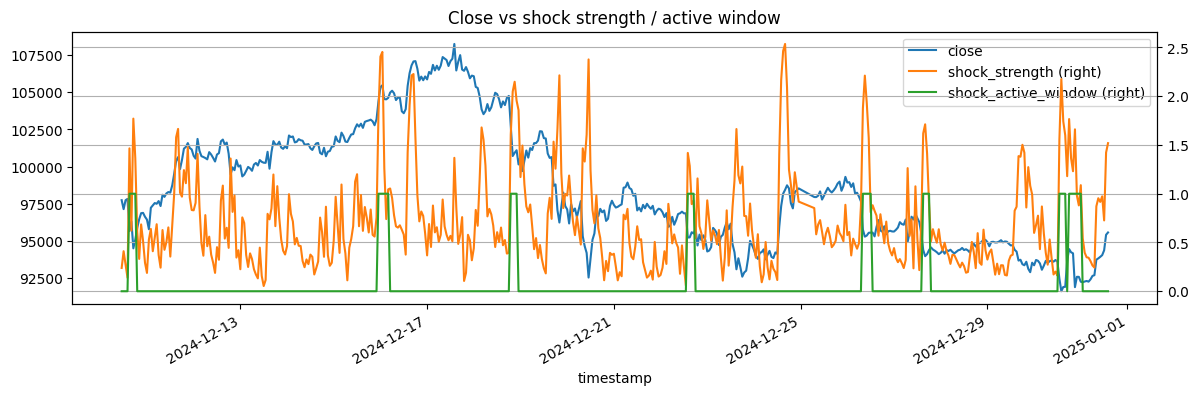

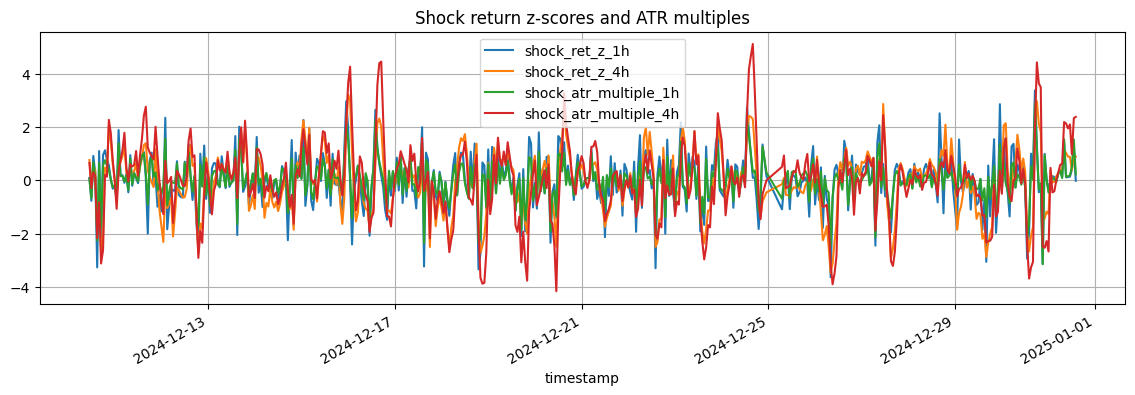

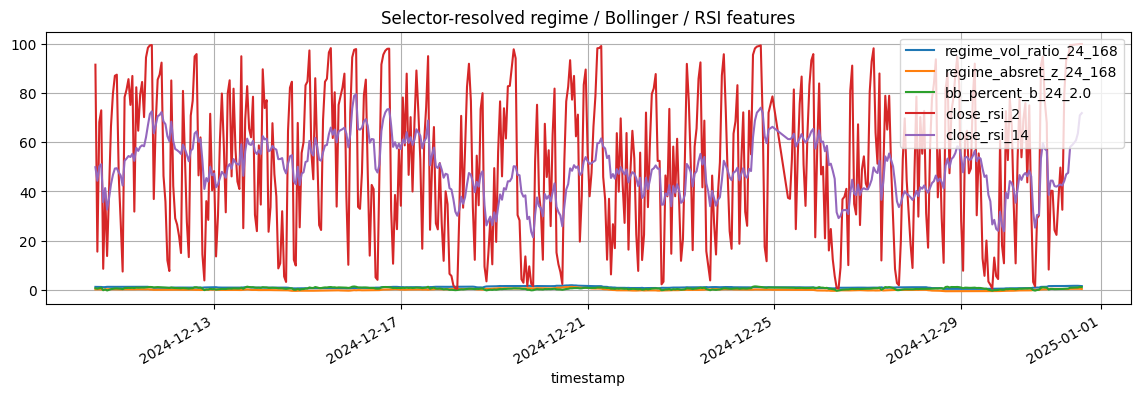

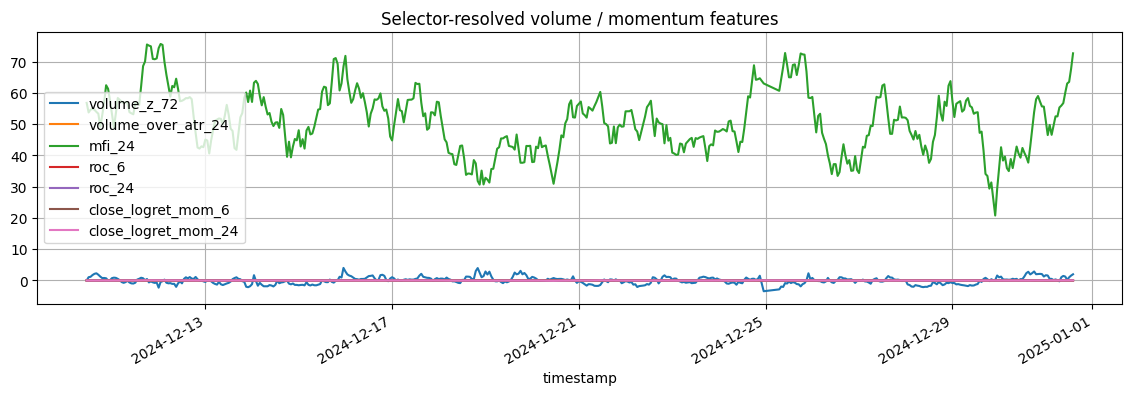

<Axes: title={'center': 'Selector-resolved volume / momentum features'}, xlabel='timestamp'>

In [6]:
# Visual checks: price, shock state, and selected model features.
plot_start = preview_features.index[-500] if len(preview_features) > 500 else None
plot_series(
    preview_features,
    ['close', 'shock_strength', 'shock_active_window'],
    title='Close vs shock strength / active window',
    start=plot_start,
    secondary_y=['shock_strength', 'shock_active_window'],
)
plot_series(
    preview_features,
    ['shock_ret_z_1h', 'shock_ret_z_4h', 'shock_atr_multiple_1h', 'shock_atr_multiple_4h'],
    title='Shock return z-scores and ATR multiples',
    start=plot_start,
)
plot_series(
    preview_features,
    [col for col in resolved_feature_cols if col.startswith(('regime_vol_ratio_', 'regime_absret_z_', 'bb_percent_b_', 'close_rsi_'))][:6],
    title='Selector-resolved regime / Bollinger / RSI features',
    start=plot_start,
)
plot_series(
    preview_features,
    [col for col in resolved_feature_cols if col.startswith(('volume_z_', 'volume_over_atr_', 'mfi_', 'roc_', 'close_logret_mom_'))][:8],
    title='Selector-resolved volume / momentum features',
    start=plot_start,
)


## Trial Config Preview

Use this before running Optuna to verify that one sampled parameter set mutates only the intended config paths.


In [7]:
manual_trial_params = {}
for dim in SEARCH_SPACE:
    if dim.kind == 'categorical':
        manual_trial_params[dim.name] = list(dim.choices or [])[0]
    elif dim.kind == 'int':
        manual_trial_params[dim.name] = int(dim.low)
    elif dim.kind == 'float':
        manual_trial_params[dim.name] = float(dim.low)
    else:
        manual_trial_params[dim.name] = False

trial_cfg = prepare_trial_config(
    BASE_CFG,
    trial_params=manual_trial_params,
    search_space=SEARCH_SPACE,
    logging_enabled=False,
)
validate_resolved_config(trial_cfg)

trial_preview_rows = []
for dim in SEARCH_SPACE:
    before = BASE_CFG
    after = trial_cfg
    for token in str(dim.path).split('.'):
        token = int(token) if token.isdigit() else token
        before = before[token]
        after = after[token]
    trial_preview_rows.append({'name': dim.name, 'path': dim.path, 'base_value': before, 'trial_value': after})

show_df('Manual first-choice trial mutation preview', pd.DataFrame(trial_preview_rows), rows=len(trial_preview_rows))


### Manual first-choice trial mutation preview

,name,path,base_value,trial_value
0,regime_vol_short_window,features.2.params.vol_short_window,24.00,12.00
1,regime_vol_long_window,features.2.params.vol_long_window,168.00,96.00
2,bollinger_window,features.3.params.window,24.00,12.00
3,bollinger_n_std,features.3.params.n_std,2.00,1.50
4,shock_ema_window,features.5.params.ema_window,24.00,12.00
5,shock_atr_window,features.5.params.atr_window,24.00,12.00
6,shock_vol_window,features.5.params.vol_window,24.00,12.00
7,shock_ret_z_threshold,features.5.params.ret_z_threshold,2.75,1.50
8,shock_atr_mult_threshold,features.5.params.atr_mult_threshold,1.75,1.00
9,shock_distance_threshold,features.5.params.distance_from_mean_threshold,1.00,0.50


,name,path,base_value,trial_value
0,regime_vol_short_window,features.2.params.vol_short_window,24.00,12.00
1,regime_vol_long_window,features.2.params.vol_long_window,168.00,96.00
2,bollinger_window,features.3.params.window,24.00,12.00
3,bollinger_n_std,features.3.params.n_std,2.00,1.50
4,shock_ema_window,features.5.params.ema_window,24.00,12.00
5,shock_atr_window,features.5.params.atr_window,24.00,12.00
6,shock_vol_window,features.5.params.vol_window,24.00,12.00
7,shock_ret_z_threshold,features.5.params.ret_z_threshold,2.75,1.50
8,shock_atr_mult_threshold,features.5.params.atr_mult_threshold,1.75,1.00
9,shock_distance_threshold,features.5.params.distance_from_mean_threshold,1.00,0.50


## Baseline Run

Set `RUN_BASELINE = True` in the config cell to run the base shock-meta XGBoost pipeline and build the analysis frame used by the plots below. This can take time because it runs walk-forward XGBoost and backtest logic.


In [8]:
baseline_result = None
baseline_frame = pd.DataFrame()

if RUN_BASELINE:
    baseline_result = run_experiment_from_config(
        BASE_CFG,
        config_path=BASE_CONFIG_PATH,
        logging_enabled=False,
    )
    baseline_summary = build_summary_frame(baseline_result.evaluation.get('primary_summary', {}))
    baseline_frame = build_analysis_frame_from_result(baseline_result)
    show_df('Baseline primary summary', baseline_summary, rows=len(baseline_summary))
else:
    display(Markdown('Baseline run is disabled. Set `RUN_BASELINE = True` to execute it.'))


### Baseline primary summary

,metric,value
0,sharpe,-1.477360
1,sortino,-1.967315
2,calmar,-0.294845
3,annualized_return,-0.228435
4,annualized_vol,0.154624
5,cumulative_return,-0.768512
6,net_pnl,-1.395627
7,gross_pnl,-0.853527
8,total_cost,0.542100
9,cost_drag,0.542100


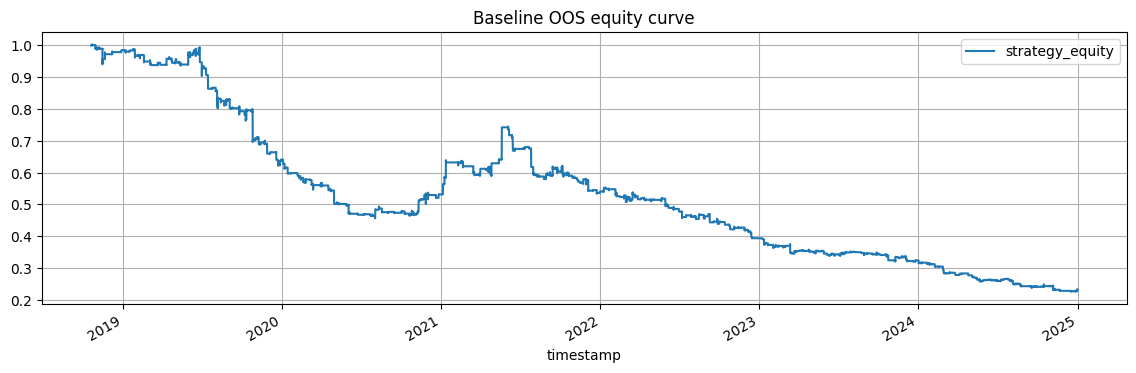

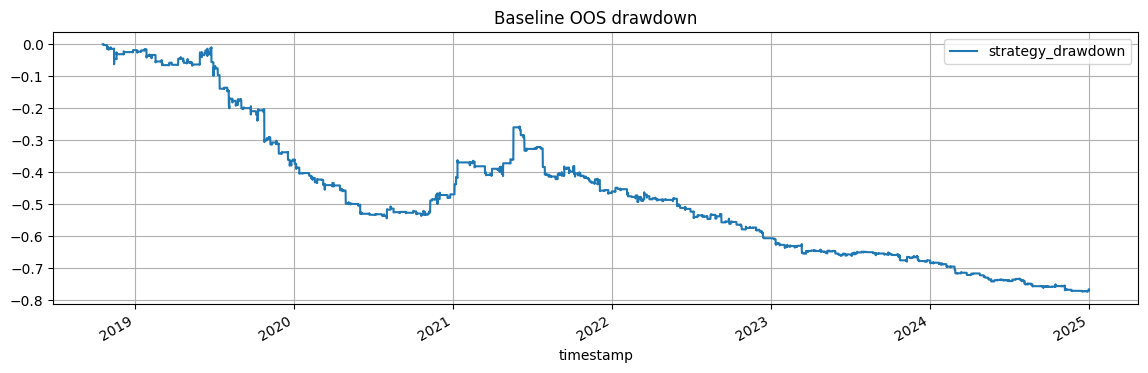

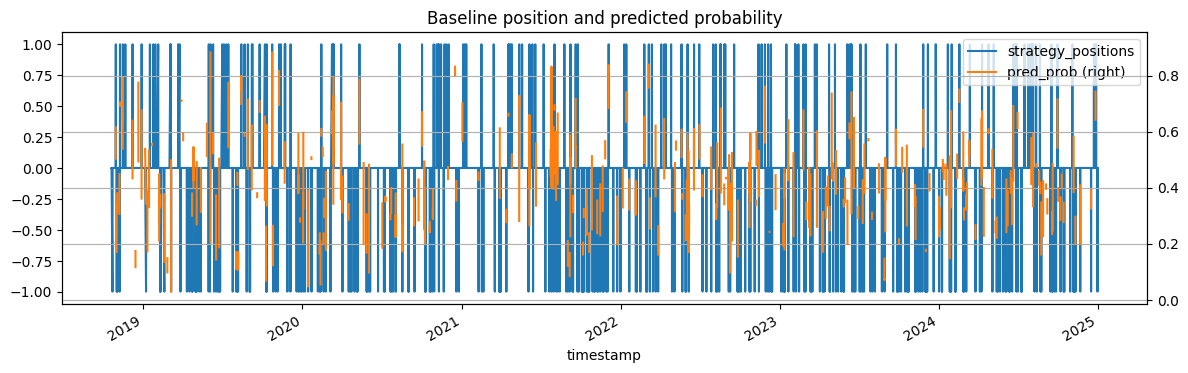

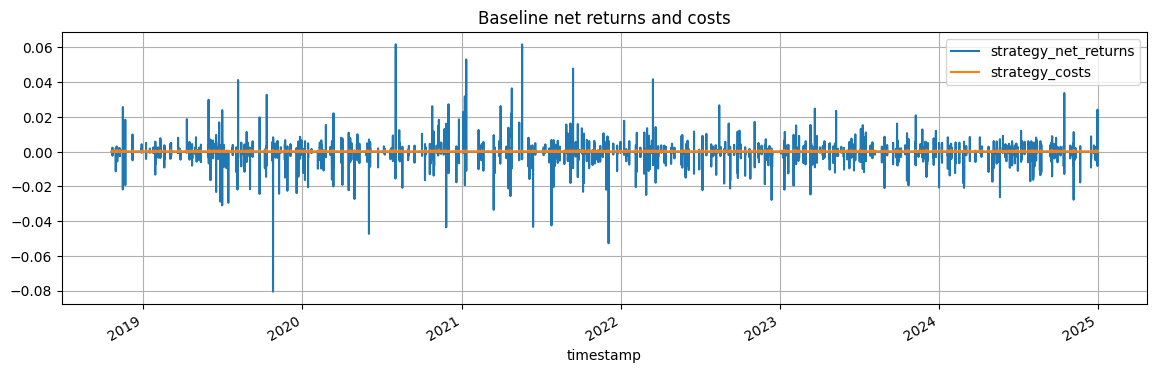

In [9]:
if not baseline_frame.empty:
    oos = baseline_frame.loc[baseline_frame.get('oos_mask', True).astype(bool)].copy()
    plot_series(oos, ['strategy_equity'], title='Baseline OOS equity curve')
    plot_series(oos, ['strategy_drawdown'], title='Baseline OOS drawdown')
    plot_series(oos, ['strategy_positions', 'pred_prob'], title='Baseline position and predicted probability', secondary_y=['pred_prob'])
    plot_series(oos, ['strategy_net_returns', 'strategy_costs'], title='Baseline net returns and costs')
else:
    display(Markdown('No baseline plots yet. Run the baseline cell first.'))


## Optuna Study

Set `RUN_OPTUNA = True` only after the feature preview and trial config preview are clean. Start with `N_TRIALS_OVERRIDE = 3` or `5` for a smoke run, then increase slowly.

The key table below ranks only `COMPLETE` trials. `PRUNED` trials may carry positive intermediate ROC-AUC values, but those are not final trading objective values.


In [10]:
study = None
trials_df = pd.DataFrame()
completed_trials_df = pd.DataFrame()
clean_completed_trials_df = pd.DataFrame()
pruned_trials_df = pd.DataFrame()
failed_trials_df = pd.DataFrame()

if RUN_OPTUNA:
    n_trials = int(N_TRIALS_OVERRIDE or STUDY_CFG.get('n_trials', 30))
    study = optimize_experiment(
        BASE_CONFIG_PATH,
        search_space=SEARCH_SPACE,
        objective=OBJECTIVE,
        pruning=PRUNING,
        study_name=STUDY_CFG.get('study_name'),
        storage=STUDY_CFG.get('storage'),
        load_if_exists=bool(STUDY_CFG.get('load_if_exists', False)),
        sampler=str(STUDY_CFG.get('sampler', 'tpe')),
        seed=STUDY_CFG.get('seed', 7),
        n_trials=n_trials,
        timeout=STUDY_CFG.get('timeout'),
        n_jobs=int(STUDY_CFG.get('n_jobs', 1)),
        logging_enabled=bool(STUDY_CFG.get('logging_enabled', False)),
        catch_exceptions=bool(STUDY_CFG.get('catch_exceptions', True)),
    )
    trials_df = study.trials_dataframe()
    state = trials_df['state'].astype(str) if 'state' in trials_df.columns else pd.Series('', index=trials_df.index)
    completed_trials_df = trials_df.loc[state.eq('COMPLETE')].copy()
    pruned_trials_df = trials_df.loc[state.eq('PRUNED')].copy()
    failed_trials_df = completed_trials_df.loc[_bool_col(completed_trials_df, 'user_attrs_trial_failed')].copy()
    clean_completed_trials_df = completed_trials_df.loc[~_bool_col(completed_trials_df, 'user_attrs_trial_failed')].copy()

    display(Markdown(
        f'### Trial state summary\n'
        f'- total: `{len(trials_df)}`\n'
        f'- complete: `{len(completed_trials_df)}`\n'
        f'- pruned: `{len(pruned_trials_df)}`\n'
        f'- failed complete: `{len(failed_trials_df)}`'
    ))

    ascending = OBJECTIVE.direction == 'minimize'
    completed_sorted = clean_completed_trials_df.sort_values('value', ascending=ascending)
    pruned_sorted = pruned_trials_df.sort_values('number')

    show_df('Completed trials ranked by final trading objective', completed_sorted, rows=min(len(completed_sorted), 25))
    if not failed_trials_df.empty:
        fail_cols = [col for col in ['number', 'value', 'user_attrs_exception', 'state'] if col in failed_trials_df.columns]
        show_df('Failed complete trials', failed_trials_df.loc[:, fail_cols], rows=len(failed_trials_df))
    if not pruned_sorted.empty:
        prune_cols = [col for col in ['number', 'value', 'user_attrs_pruning_reports', 'state'] if col in pruned_sorted.columns]
        show_df('Pruned trials (intermediate pruning values, not final objective)', pruned_sorted.loc[:, prune_cols], rows=min(len(pruned_sorted), 25))

    if clean_completed_trials_df.empty:
        display(Markdown('No clean completed trial is available yet. Increase `N_TRIALS_OVERRIDE` or relax pruning.'))
    elif study.best_trial.user_attrs.get('primary_summary'):
        show_df('Best completed trial params', pd.DataFrame([study.best_params]).T.rename(columns={0: 'value'}), rows=len(study.best_params))
        show_df('Best completed trial primary summary', build_summary_frame(study.best_trial.user_attrs['primary_summary']))
else:
    display(Markdown('Optuna run is disabled. Set `RUN_OPTUNA = True` to execute it.'))


[I 2026-04-11 13:00:26,291] A new study created in memory with name: optuna_shock_meta_xgboost_v2
[I 2026-04-11 13:00:53,930] Trial 0 finished with value: -8.216325122769419 and parameters: {'regime_vol_short_window': 24, 'regime_vol_long_window': 168, 'bollinger_window': 12, 'bollinger_n_std': 2.4, 'shock_ema_window': 12, 'shock_atr_window': 48, 'shock_vol_window': 36, 'shock_ret_z_threshold': 2.5, 'shock_atr_mult_threshold': 2.5, 'shock_distance_threshold': 0.5, 'post_shock_active_bars': 2, 'rsi_fast_window': 3, 'rsi_slow_window': 21, 'volume_vol_z_window': 48, 'volume_atr_window': 24, 'mfi_window': 14, 'roc_fast_window': 12, 'roc_slow_window': 48, 'return_mom_fast_window': 6, 'return_mom_slow_window': 24, 'tb_max_holding': 48, 'tb_upper_mult': 2.0, 'tb_lower_mult': 1.0, 'tb_vol_window': 48, 'xgb_n_estimators': 600, 'xgb_learning_rate': 0.05836901176866002, 'xgb_max_depth': 4, 'xgb_min_child_weight': 11.0, 'xgb_subsample': 0.6, 'xgb_colsample_bytree': 0.7, 'xgb_reg_lambda': 0.8433207

### Trial state summary
- total: `30`
- complete: `22`
- pruned: `8`
- failed complete: `2`

### Completed trials ranked by final trading objective

,number,value,datetime_start,datetime_complete,duration,params_backtest_min_holding_bars,params_bollinger_n_std,params_bollinger_window,params_dd_guard_cooloff_bars,params_dd_guard_max_drawdown,params_dd_guard_rearm_drawdown,params_mfi_window,params_post_shock_active_bars,params_regime_vol_long_window,params_regime_vol_short_window,params_return_mom_fast_window,params_return_mom_slow_window,params_risk_max_leverage,params_roc_fast_window,params_roc_slow_window,params_rsi_fast_window,params_rsi_slow_window,params_shock_atr_mult_threshold,params_shock_atr_window,params_shock_distance_threshold,params_shock_ema_window,params_shock_ret_z_threshold,params_shock_vol_window,params_signal_lower,params_signal_lower_exit,params_signal_upper,params_signal_upper_exit,params_tb_lower_mult,params_tb_max_holding,params_tb_upper_mult,params_tb_vol_window,params_volume_atr_window,params_volume_vol_z_window,params_xgb_colsample_bytree,params_xgb_learning_rate,params_xgb_max_depth,params_xgb_min_child_weight,params_xgb_n_estimators,params_xgb_reg_lambda,params_xgb_subsample,user_attrs_derived_metrics,user_attrs_exception,user_attrs_fold_backtest_summaries,user_attrs_objective_direction,user_attrs_objective_metric,user_attrs_primary_summary,user_attrs_pruning_reports,user_attrs_trial_failed,user_attrs_trial_params,state
24,24,-2.044325,2026-04-11 13:06:37.029628,2026-04-11 13:06:50.185117,0 days 00:00:13.155489,8,1.7,48,72,0.10,0.10,24,1,336,12,12,48,0.50,6,24,4,10,1.25,12,1.75,48,3.25,24,0.40,0.46,0.55,0.50,1.00,12,2.50,48,12,168,0.6,0.016103,3,9.0,350,0.191234,0.9,{'trade_count': 24.0},NaN,"[{'fold': 0, 'test_rows': 336, 'metrics': {'cu...",maximize,evaluation.primary_summary.sharpe,"{'cumulative_return': 0.03794940883285203, 'an...","[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",False,"{'regime_vol_short_window': 12, 'regime_vol_lo...",COMPLETE
21,21,-2.351434,2026-04-11 13:05:51.250683,2026-04-11 13:06:07.096361,0 days 00:00:15.845678,8,1.7,48,72,0.10,0.10,24,1,336,12,12,48,0.50,6,24,4,10,1.25,12,1.75,48,2.75,24,0.40,0.46,0.55,0.50,1.25,12,2.50,48,12,168,0.8,0.012616,3,7.0,300,0.529581,1.0,{'trade_count': 94.0},NaN,"[{'fold': 0, 'test_rows': 336, 'metrics': {'cu...",maximize,evaluation.primary_summary.sharpe,"{'cumulative_return': -0.0008006024330275974, ...","[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",False,"{'regime_vol_short_window': 12, 'regime_vol_lo...",COMPLETE
25,25,-2.502010,2026-04-11 13:06:50.189036,2026-04-11 13:07:04.452418,0 days 00:00:14.263382,8,2.0,48,72,0.10,0.10,24,1,336,12,12,48,0.50,6,24,4,10,1.25,12,1.75,48,2.75,24,0.42,0.46,0.55,0.50,1.00,12,2.25,48,12,168,0.6,0.015998,3,9.0,300,0.206931,0.9,{'trade_count': 60.0},NaN,"[{'fold': 0, 'test_rows': 336, 'metrics': {'cu...",maximize,evaluation.primary_summary.sharpe,"{'cumulative_return': -0.02130861785442162, 'a...","[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",False,"{'regime_vol_short_window': 12, 'regime_vol_lo...",COMPLETE
27,27,-2.613789,2026-04-11 13:07:17.145126,2026-04-11 13:07:34.067918,0 days 00:00:16.922792,8,1.6,48,72,0.10,0.10,24,1,336,12,12,48,0.50,6,24,4,10,1.25,12,1.75,48,2.75,24,0.43,0.46,0.55,0.50,1.00,12,2.25,48,12,168,0.6,0.012431,3,9.0,350,0.197155,0.9,{'trade_count': 60.0},NaN,"[{'fold': 0, 'test_rows': 336, 'metrics': {'cu...",maximize,evaluation.primary_summary.sharpe,"{'cumulative_return': -0.029840824042618674, '...","[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",False,"{'regime_vol_short_window': 12, 'regime_vol_lo...",COMPLETE
26,26,-3.395782,2026-04-11 13:07:04.456090,2026-04-11 13:07:17.141104,0 days 00:00:12.685014,8,1.8,48,72,0.10,0.10,24,1,336,12,12,48,0.50,6,24,4,10,1.25,12,1.50,48,2.75,24,0.43,0.46,0.58,0.50,1.00,12,2.25,48,12,168,0.6,0.016150,3,10.0,200,0.195654,1.0,{'trade_count': 70.0},NaN,"[{'fold': 0, 'test_rows': 336, 'metrics': {'cu...",maximize,evaluation.primary_summary.sharpe,"{'cumulative_return': -0.12665580807049848, 'a...","[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",False,"{'regime_vol_short_win

### Failed complete trials

...

,number,value,user_attrs_pruning_reports,state
6,6,0.385417,"[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",PRUNED
7,7,0.500000,"[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",PRUNED
10,10,0.409091,"[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",PRUNED
11,11,0.473958,"[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",PRUNED
15,15,0.571429,"[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",PRUNED
18,18,0.567308,"[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",PRUNED
28,28,0.744444,"[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",PRUNED
29,29,0.750000,"[{'stage': 'xgboost_clf', 'fold': 0, 'step': 0...",PRUNED


### Best completed trial params

,value
regime_vol_short_window,12.000000
regime_vol_long_window,336.000000
bollinger_window,48.000000
bollinger_n_std,1.700000
shock_ema_window,48.000000
shock_atr_window,12.000000
shock_vol_window,24.000000
shock_ret_z_threshold,3.250000
shock_atr_mult_threshold,1.250000
shock_distance_threshold,1.750000


### Best completed trial primary summary

,metric,value
0,sharpe,0.370325
1,sortino,0.668373
2,calmar,0.286228
3,annualized_return,0.006623
4,annualized_vol,0.017885
5,cumulative_return,0.037949
6,net_pnl,0.038145
7,gross_pnl,0.045945
8,total_cost,0.007800
9,cost_drag,0.007800


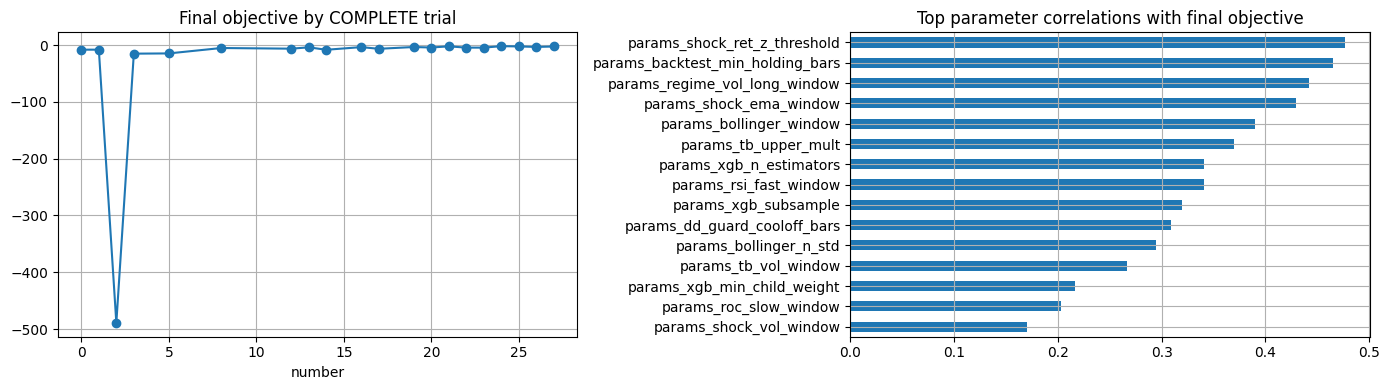

In [11]:
if not clean_completed_trials_df.empty:
    numeric_cols = [col for col in clean_completed_trials_df.columns if col.startswith('params_')]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    clean_completed_trials_df[['number', 'value']].dropna().plot(x='number', y='value', marker='o', ax=axes[0], grid=True, legend=False)
    axes[0].set_title('Final objective by COMPLETE trial')
    if numeric_cols:
        corr_input = clean_completed_trials_df[numeric_cols + ['value']].apply(pd.to_numeric, errors='coerce')
        corr = corr_input.corr(numeric_only=True)['value'].drop('value').dropna().sort_values()
        if not corr.empty:
            corr.tail(15).plot(kind='barh', ax=axes[1], grid=True)
            axes[1].set_title('Top parameter correlations with final objective')
        else:
            axes[1].axis('off')
    else:
        axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('No completed Optuna study results yet.'))


## Best Trial Re-run

This cell materializes the best trial into the same base pipeline and optionally re-runs it. Keep this separate from the study run so you can inspect the chosen parameters before spending more time.


In [12]:
best_trial_cfg = None
best_trial_result = None
best_trial_frame = pd.DataFrame()

if study is not None and not clean_completed_trials_df.empty:
    best_trial_cfg = prepare_trial_config(
        BASE_CFG,
        trial_params=study.best_params,
        search_space=SEARCH_SPACE,
        logging_enabled=False,
    )
    validate_resolved_config(best_trial_cfg)
    show_df('Best trial feature steps', pd.DataFrame([
        {'idx': idx, 'step': step.get('step'), 'params': step.get('params', {})}
        for idx, step in enumerate(best_trial_cfg.get('features', []))
    ]), rows=len(best_trial_cfg.get('features', [])))

    if RUN_BEST_TRIAL:
        best_trial_result = run_experiment_from_config(
            best_trial_cfg,
            config_path=BASE_CONFIG_PATH,
            logging_enabled=False,
        )
        best_trial_frame = build_analysis_frame_from_result(best_trial_result)
        best_summary = best_trial_result.evaluation.get('primary_summary', {})
        show_df('Best trial primary summary', build_summary_frame(best_summary))
        if baseline_result is not None:
            baseline_summary = baseline_result.evaluation.get('primary_summary', {})
            show_df(
                'Best trial vs baseline metrics',
                metric_comparison_frame(baseline_summary=baseline_summary, candidate_summary=best_summary),
                rows=20,
            )
        else:
            display(Markdown('Baseline comparison skipped because `RUN_BASELINE` is disabled.'))
elif study is not None:
    display(Markdown('No clean completed trial is available to materialize. Increase `N_TRIALS_OVERRIDE` or relax pruning.'))
else:
    display(Markdown('Run Optuna first to materialize a best-trial config.'))


### Best trial feature steps

,idx,step,params
0,0,returns,"{'log': True, 'col_name': 'close_logret'}"
1,1,trend,"{'price_col': 'close', 'sma_windows': [], 'ema..."
2,2,regime_context,"{'price_col': 'close', 'returns_col': 'close_l..."
3,3,bollinger,"{'price_col': 'close', 'window': 48, 'n_std': ..."
4,4,atr,"{'high_col': 'high', 'low_col': 'low', 'close_..."
5,5,shock_context,"{'price_col': 'close', 'high_col': 'high', 'lo..."
6,6,rsi,"{'price_col': 'close', 'windows': [4, 10], 'me..."
7,7,lags,"{'cols': ['close_logret'], 'lags': [1]}"
8,8,volume_features,"{'volume_col': 'volume', 'atr_col': None, 'hig..."
9,9,mfi,"{'high_col': 'high', 'low_col': 'low', 'close_..."


### Best trial primary summary

,metric,value
0,sharpe,0.370325
1,sortino,0.668373
2,calmar,0.286228
3,annualized_return,0.006623
4,annualized_vol,0.017885
5,cumulative_return,0.037949
6,net_pnl,0.038145
7,gross_pnl,0.045945
8,total_cost,0.007800
9,cost_drag,0.007800


### Best trial vs baseline metrics

,metric,baseline,candidate,delta
0,sharpe,-1.477360,0.370325,1.847685
1,sortino,-1.967315,0.668373,2.635688
2,cumulative_return,-0.768512,0.037949,0.806462
3,annualized_return,-0.228435,0.006623,0.235059
4,profit_factor,0.753938,1.366296,0.612358
5,hit_rate,0.406100,0.490741,0.084641
6,max_drawdown,-0.774763,-0.023140,0.751624
7,gross_pnl,-0.853527,0.045945,0.899472
8,net_pnl,-1.395627,0.038145,1.433772
9,total_cost,0.542100,0.007800,-0.534300


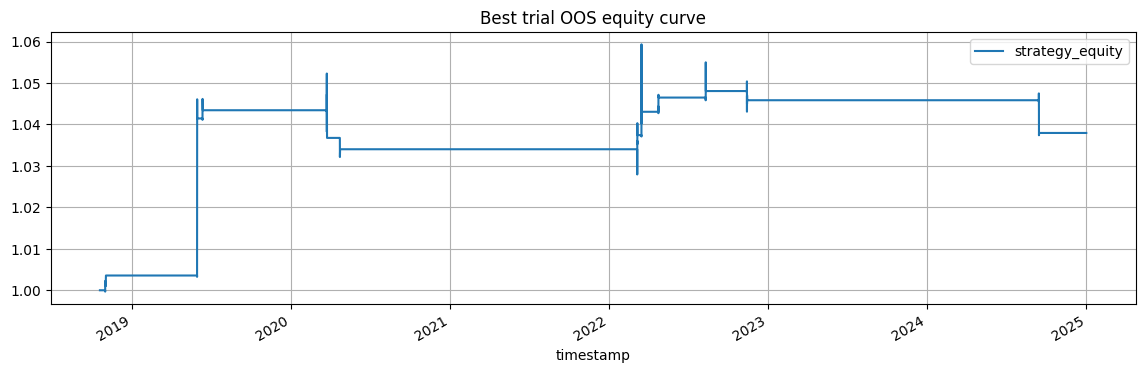

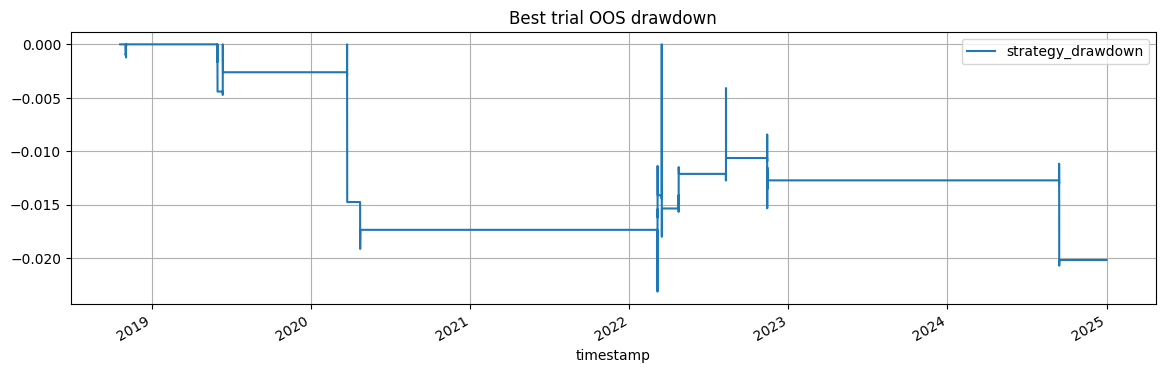

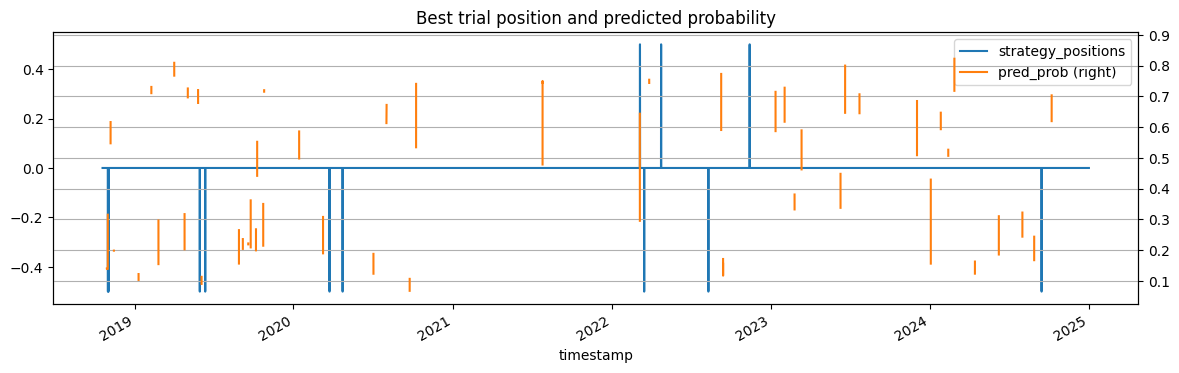

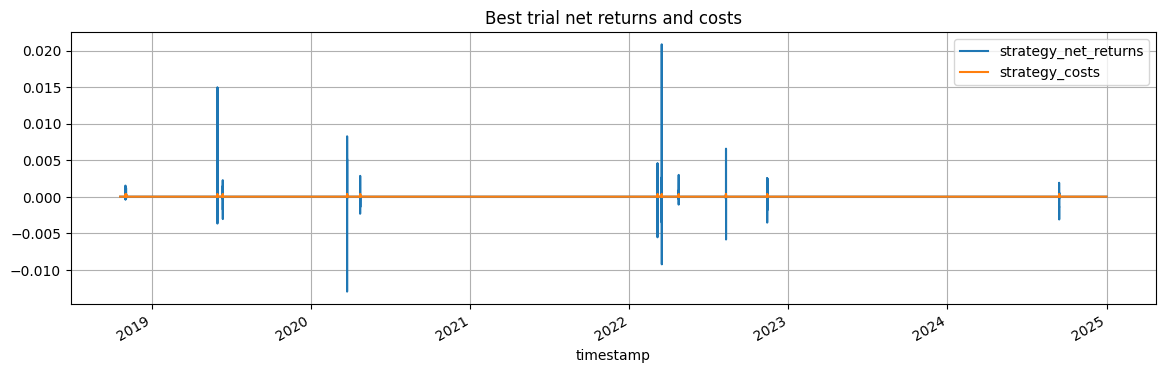

In [13]:
if not best_trial_frame.empty:
    oos = best_trial_frame.loc[best_trial_frame.get('oos_mask', True).astype(bool)].copy()
    plot_series(oos, ['strategy_equity'], title='Best trial OOS equity curve')
    plot_series(oos, ['strategy_drawdown'], title='Best trial OOS drawdown')
    plot_series(oos, ['strategy_positions', 'pred_prob'], title='Best trial position and predicted probability', secondary_y=['pred_prob'])
    plot_series(oos, ['strategy_net_returns', 'strategy_costs'], title='Best trial net returns and costs')
else:
    display(Markdown('No best-trial plots yet. Set `RUN_BEST_TRIAL = True` after an Optuna run.'))


## Notes

- If many trials fail with selector errors, reduce the search space before expanding it.
- If best trials have low `derived.trade_count`, increase the trade-count penalty or narrow signal thresholds.
- If fold Sharpe dispersion is high, increase `objective.stability_weight` or shrink the model parameter space.
- The next production step is to promote only a small, stable set of tuned params back into a separate experiment config and re-test OOS.
